# 10 · Holdout comparison (v1 vs v2)

Score saved v1 and v2 models on the **same** untouched holdout. This is the head-to-head quality table, plus agreement, directional disagreements, and PSI drift.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from cross_model_drift.compare import DRIFT_COLUMNS, compare_models, result_payload
from cross_model_drift.data import load_split
from cross_model_drift.metrics import feature_psi_table
from cross_model_drift.models import load_model
from cross_model_drift.notebook import setup_model_session
from cross_model_drift.tracking import clearml_task, log_metrics

nb = setup_model_session()
holdout = load_split("v1", "holdout", nb.config, engine=nb.engine)
reference = load_split("v1", "train", nb.config, engine=nb.engine)
v1 = load_model(nb.artifacts / "models" / "v1_champion_challenger.joblib")
v2 = load_model(nb.artifacts / "models" / "v2_champion_challenger.joblib")
result = compare_models(holdout, v1, v2, reference=reference, threshold=nb.threshold)
result.quality

,metric,v1,v2
0,precision,0.702611,0.703690
1,recall,0.333601,0.330033
2,f1,0.452401,0.449329
3,pr_auc,0.392633,0.392304
4,roc_auc,0.855241,0.855949
5,agreement,NaN,0.999301
6,v1_neg_v2_pos,NaN,0.000290
7,v1_pos_v2_neg,NaN,0.000409


In [4]:
(nb.artifacts / "reports").mkdir(parents=True, exist_ok=True)
result.predictions.to_parquet(nb.artifacts / "reports" / "holdout_predictions.parquet", index=False)
result.quality.to_csv(nb.artifacts / "reports" / "holdout_quality.csv", index=False)
payload = result_payload(result)
with clearml_task("compare_champion_challenger", config=nb.config, task_type="qc", tags=["compare"], init=True) as task:
    log_metrics(task, result.v1_metrics, title="v1")
    log_metrics(task, result.v2_metrics, title="v2")
payload

ClearML Task: created new task id=565927347a4c49ae9580e7c60b277dc6
ClearML results page: http://localhost:8080/projects/23d7eaf499d345e2b9df79587a66a66c/tasks/565927347a4c49ae9580e7c60b277dc6/output/log
2026-08-23 20:16:28,737 - clearml.resource_monitor - WARNING - Could not fetch GPU stats: NVML Shared Library Not Found


{'v1': {'precision': 0.7026113094119857,
  'recall': 0.3336009276603336,
  'f1': 0.4524011128583525,
  'pr_auc': 0.39263300264335643,
  'roc_auc': 0.8552413611132774,
  'threshold': 0.5,
  'n': 544798,
  'n_positive': 11211,
  'positive_rate': 0.02057826937690667},
 'v2': {'precision': 0.7036896158235071,
  'recall': 0.33003300330033003,
  'f1': 0.44932904244337846,
  'pr_auc': 0.3923040908669976,
  'roc_auc': 0.8559493694631399,
  'threshold': 0.5,
  'n': 544798,
  'n_positive': 11211,
  'positive_rate': 0.02057826937690667},
 'agreement': {'agreement': 0.9993006582256175,
  'v1_neg_v2_pos': 0.00029001574895649396,
  'v1_pos_v2_neg': 0.00040932602542593767,
  'n': 544798},
 'score_jsd': 0.00038437442859194957,
 'promote_v2': False}

## Score distributions

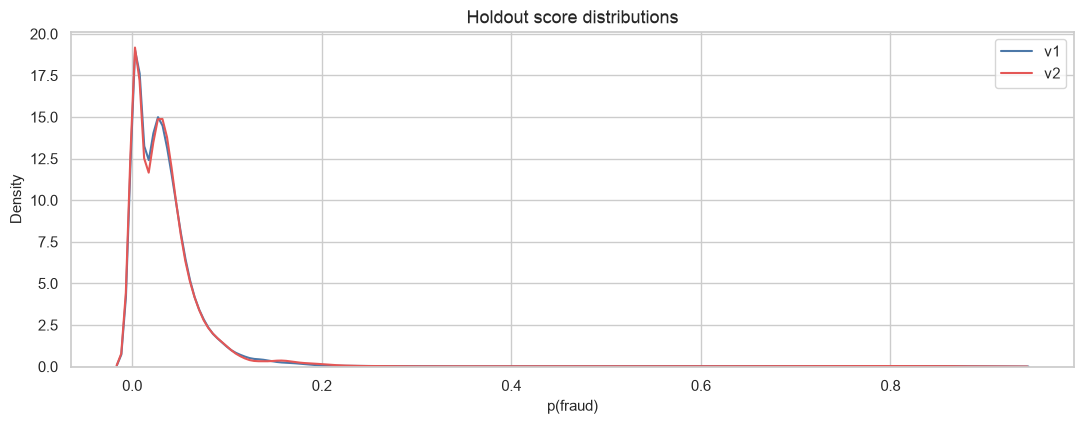

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.4))
sns.kdeplot(result.predictions["v1_score"], ax=ax, label="v1", color="#4C78A8")
sns.kdeplot(result.predictions["v2_score"], ax=ax, label="v2", color="#E45756")
ax.set_title("Holdout score distributions")
ax.set_xlabel("p(fraud)")
ax.legend()
nb.show(fig)

## Agreement and directional disagreements

Operational view: where v1 and v2 vote the same, and where they flip.

In [6]:
preds = result.predictions
n = len(preds)
summary = pd.Series(
    {
        "agreement": (preds["v1_pred"] == preds["v2_pred"]).mean(),
        "v1_neg_v2_pos": ((preds["v1_pred"] == 0) & (preds["v2_pred"] == 1)).mean(),
        "v1_pos_v2_neg": ((preds["v1_pred"] == 1) & (preds["v2_pred"] == 0)).mean(),
        "n": n,
    }
)
summary

agreement             0.999301
v1_neg_v2_pos         0.000290
v1_pos_v2_neg         0.000409
n                544798.000000
dtype: float64

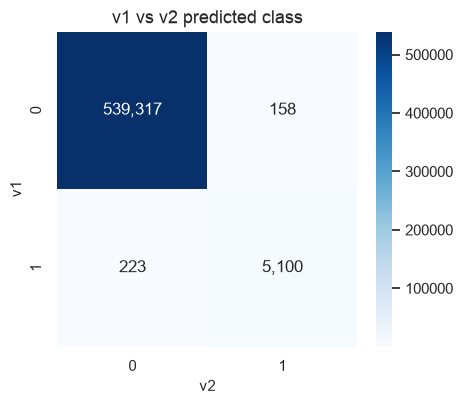

v2,0,1
v1,,
0,539317,158
1,223,5100


In [7]:
confusion = pd.crosstab(preds["v1_pred"], preds["v2_pred"], rownames=["v1"], colnames=["v2"])
fig, ax = plt.subplots(figsize=(4.8, 4.2))
sns.heatmap(confusion, annot=True, fmt=",d", cmap="Blues", ax=ax)
ax.set_title("v1 vs v2 predicted class")
nb.show(fig)
confusion

In [8]:
flips = preds.loc[preds["v1_pred"] != preds["v2_pred"]].copy()
flips["direction"] = np.where(flips["v2_pred"] == 1, "v1 NEG → v2 POS", "v1 POS → v2 NEG")
flips.groupby("direction")["y_true"].agg(["count", "mean"]).rename(columns={"mean": "fraud_rate"})

,count,fraud_rate
direction,,
v1 NEG → v2 POS,158,0.518987
v1 POS → v2 NEG,223,0.547085


## PSI / data drift

Compare a reference window (v1 train) with the final holdout on the plan's drift features. Volume is traffic, not model drift by itself.

In [9]:
psi = feature_psi_table(reference, holdout, DRIFT_COLUMNS)
psi

,feature,kind,psi
0,payout_country,categorical,0.009434
1,payout_currency,categorical,0.008963
2,amount_usd,numeric,0.000214
3,fee_usd,numeric,0.023940
4,hour_of_day,numeric,0.000341


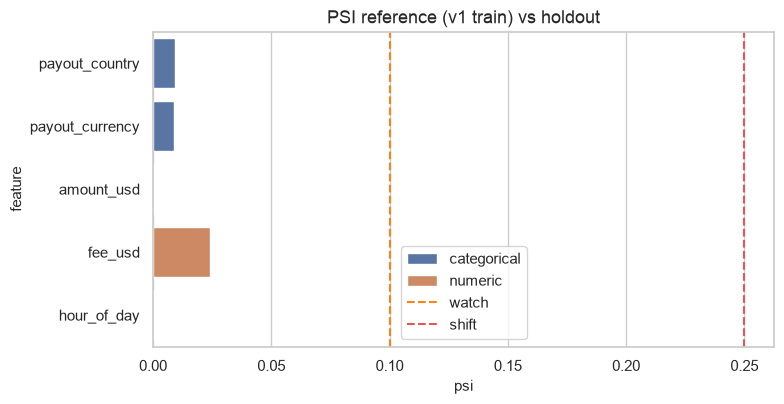

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.2))
sns.barplot(data=psi, y="feature", x="psi", hue="kind", ax=ax)
ax.axvline(0.1, color="#F58518", linestyle="--", label="watch")
ax.axvline(0.25, color="#E45756", linestyle="--", label="shift")
ax.set_title("PSI reference (v1 train) vs holdout")
ax.legend()
nb.show(fig)
psi.to_csv(nb.artifacts / "reports" / "psi_holdout.csv", index=False)

In [11]:
volume = nb.read_sql(
    f"""
    SELECT
        SUM(created >= '{reference["created"].min().date()}' AND created < '{reference["created"].max().date() + pd.Timedelta(days=1)}') AS v1_train_n,
        SUM(created >= '{holdout["created"].min().date()}' AND created < '{holdout["created"].max().date() + pd.Timedelta(days=1)}') AS holdout_n
    FROM `{nb.table}`
    """
)
volume

,v1_train_n,holdout_n
0,4981627.0,544798.0
